# <b><font color='forestgreen'>Бенчмарки и LazyFrame</font></b>

### <font color='forestgreen'>1. Создание LazyFrame</font>

In [1]:
# Импорт библиотек
import polars as pl

##### <font color='forestgreen'>1.1. От DataFrames к LazyFrames</font>

In [2]:
df = pl.DataFrame({
    "name": ["Alice", "Bob", "Charlie"],
    "age": [25, 30, 35],
    "city": ["New York", "Los Angeles", "Chicago"]
})

lazy_df = df.lazy()
lazy_df

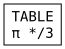

In [3]:
lazy_df.show_graph()

In [4]:
lazy_df.collect()

name,age,city
str,i64,str
"""Alice""",25,"""New York"""
"""Bob""",30,"""Los Angeles"""
"""Charlie""",35,"""Chicago"""


##### <font color='forestgreen'>1.2. Чтение данных в LazyFrame</font>

In [5]:
lazy_df_from_csv = pl.read_csv("events.csv").lazy()
lazy_df_from_csv

##### <font color='forestgreen'>1.3. Создание LazyFrame с нуля</font>

In [6]:
lazy_df_from_scratch = pl.DataFrame({
    "id": [1, 2, 3],
    "value": [10, 20, 30]
}).lazy()
lazy_df_from_scratch

##### <font color='forestgreen'>1.4. Операция scan</font>

In [7]:
lazy_df_from_csv_scan = pl.scan_csv("events.csv")
lazy_df_from_csv_scan

### <font color='forestgreen'>2. Преобразования LazyFrame</font>

In [20]:
result_df = (
    pl.scan_csv("events.csv")
    .select(['brand', 'event_type', 'price'])
    .filter(pl.col('event_type') == 'view')
    .group_by("brand").agg([pl.col("price").mean().alias("average_price")])
)#.collect()

print(result_df)

naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

AGGREGATE[maintain_order: false]
  [col("price").mean().alias("average_price")] BY [col("brand")]
  FROM
  FILTER [(col("event_type")) == ("view")]
  FROM
    SELECT [col("brand"), col("event_type"), col("price")]
      Csv SCAN [events.csv]
      PROJECT */9 COLUMNS
      ESTIMATED ROWS: 903951


### <font color='forestgreen'>3. Визуализация планов выполнения в Polars</font>

[Graphviz](https://graphviz.org/download/)

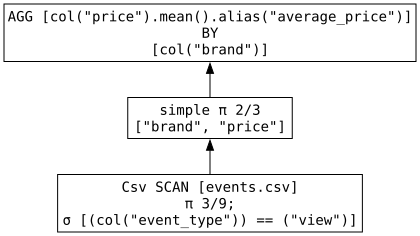

In [9]:
result_df = (
    pl.scan_csv("events.csv")
    .select(['brand', 'event_type', 'price'])
    .filter(pl.col('event_type') == 'view')
    .group_by("brand").agg([pl.col("price").mean().alias("average_price")])
)

result_df.show_graph()

### <font color='forestgreen'>4. Параметр streaming</font>

In [16]:
df = pl.read_csv("events.csv").filter(pl.col("price") > 100)
lazy_df = df.lazy()
result_df = lazy_df.collect(engine = 'streaming')
result_df

event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
str,str,i64,i64,str,str,f64,i64,str
"""2020-09-24 11:57:33 UTC""","""view""",635807,2144415923107266682,"""computers.peripherals.printer""","""pantum""",113.81,1515915625519014356,"""aGFYrNgC08"""
"""2020-09-24 11:58:23 UTC""","""view""",3791349,2144415935086199225,"""computers.desktop""",null,215.41,1515915625519388877,"""J1t6sIYXiV"""
"""2020-09-24 12:00:00 UTC""","""view""",1080093,2144415923107266682,"""computers.peripherals.printer""","""ricoh""",268.17,1515915625519389483,"""63xjTFC54g"""
"""2020-09-24 12:00:01 UTC""","""view""",1455459,2144415927049912542,"""electronics.video.tv""","""sony""",635.63,1515915625519385419,"""sF2S2yMO09"""
"""2020-09-24 12:00:39 UTC""","""view""",1021484,2144415944976368325,null,null,202.98,1515915625519389101,"""fO4BG6BTMi"""
…,…,…,…,…,…,…,…,…
"""2021-02-28 23:47:49 UTC""","""view""",1271549,2144415924424278172,"""electronics.audio.acoustic""","""edifier""",405.65,1515915625611022987,"""7geq5gYdXF"""
"""2021-02-28 23:51:25 UTC""","""view""",622796,2144415922738167921,"""computers.components.cdrw""","""asus""",147.38,1515915625572947504,"""LJ4H6CRcME"""
"""2021-02-28 23:51:25 UTC""","""view""",622796,2144415922738167921,"""computers.components.cdrw""","""asus""",147.38,1515915625572947504,"""SqlXaC3Wrw"""


### <font color='forestgreen'>5. Сравнение с pandas. Бенчмаркинг</font>

##### <font color='forestgreen'>5.1. Pandas</font>

In [17]:
%%timeit

import pandas as pd

df = pd.read_csv("events.csv")
df_selected = df[['brand', 'event_type', 'price']]
df_filtered = df_selected[df_selected['event_type'] == 'view']
result_df = df_filtered.groupby('brand')['price'].mean().reset_index(name = 'average_price')

1.32 s ± 64.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


##### <font color='forestgreen'>5.2. Polars</font>

In [18]:
%%timeit

import polars as pl

result_df = (
    pl.scan_csv("events.csv")
    .select(['brand', 'event_type', 'price'])
    .filter(pl.col('event_type') == 'view')
    .group_by("brand").agg([pl.col("price").mean().alias("average_price")])
).collect()

118 ms ± 3.71 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
